(03-15-shiller-excess-volatility)=

# Shiller en LeRoy-Porter: excess volatility

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1979–1988.

**Wat we al weten.** Sinds [](#01-03-williams-ddm) is de prijs van een aandeel de
contante waarde van verwachte dividenden, en de prijs-dividend-ratio beweegt
dus alleen als verwachte dividendgroei of de discontovoet beweegt. De
consumptiemodellen uit [](#03-12-consumptie-capm) en [](#03-13-equity-premium-puzzle)
konden de *gemiddelde* premie op aandelen niet verklaren, en Roll liet in
[](#03-14-roll) zien dat een theorie over prijzen pas iets zegt zodra je weet
tegen welke maatstaf je hem toetst. De barst die openlag: niemand had nog
gevraagd of de *beweeglijkheid* van de koersen past bij wat er later met de
dividenden gebeurde.

**Welke vraag staat open.** Bewegen aandelenprijzen meer dan de latere
dividenden kunnen rechtvaardigen?
```

## Overzicht

In juni 1981 publiceerde Robert Shiller in de *American Economic Review* een
artikel met een vraag als titel: *Do Stock Prices Move Too Much to be Justified
by Subsequent Changes in Dividends?* {cite}`Shiller1981`. Een maand eerder had
Econometrica het artikel van Stephen LeRoy en Richard Porter geplaatst dat
onafhankelijk hetzelfde idee uitwerkte {cite}`LeRoyPorter1981`. Het idee is een
ongelijkheid tussen twee varianties, en het antwoord was ja: in Shillers tabel 2
is de standaarddeviatie van de reële S&P-koers over 1871–1979 5,6 keer zo groot
als de bovengrens die het model toestaat, en voor de Dow Jones over 1928–1979
13,3 keer. Dat is het getal "vijf tot dertien" waar het vak een decennium over
heeft gestreden.

Het werk definieert het tijdvak omdat het de efficiëntiediscussie verlegde van
*voorspelbaarheid van rendementen op korte termijn*, waar de data weinig tegen
de theorie inbracht, naar *het niveau van prijzen*, waar de afwijking groot en
zichtbaar was. Het markeert ook een verschuiving in de epistemische status. Het
constante-discontovoetmodel van Williams was een theorie die getoetst werd; na
Shiller is excess volatility een *feit* met twee concurrerende verklaringen:
discontovoeten die bewegen, of prijzen die te sterk reageren.

We bouwen de ongelijkheid op met een handrekenbaar voorbeeld, bewijzen haar,
en behandelen dan de drie kritieken die haar bijna onderuit haalden: Flavin
{cite}`Flavin1983` (kleine steekproeven), Kleidon {cite}`Kleidon1986`
(niet-stationariteit) en Marsh en Merton {cite}`MarshMerton1986` (dividend
smoothing), plus het antwoord van Campbell en Shiller en van West
{cite}`CampbellShiller1987,CampbellShiller1988,West1988`. De simulatie laat zien
hoe vaak Shillers toets alarm slaat in een economie waar prijzen per constructie
rationeel zijn. Aan het eind repliceren we Shillers figuur 1 en zijn
variantieratio op `hap.data.shiller()`, en laten we zien hoe sterk dat getal
afhangt van keuzes die in de theorie niet voorkomen.

In [1]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Neem een weersvoorspeller. Elke ochtend noemt hij een getal voor de temperatuur
van vanmiddag. Achteraf kun je zijn voorspellingen naast de gemeten
temperaturen leggen. Als hij goed werkt, zijn zijn fouten onvoorspelbaar: uit
zijn eigen voorspelling kun je niet afleiden of hij te hoog of te laag zit. Maar
dan geldt ook iets over de spreiding. De gemeten temperatuur is de voorspelling
plus een fout die er los van staat, en twee losstaande bronnen van variatie
tellen op. De werkelijkheid schommelt dus altijd minstens zo veel als de
voorspelling. Een voorspeller wiens getallen wilder op en neer gaan dan het weer
zelf, voegt ruis toe.

Shiller paste dat toe op de beurs. Onder het model van Williams is de koers van
vandaag de beste voorspelling van één bepaald getal: de contante waarde van alle
dividenden die het aandeel daarna werkelijk uitkeert. Dat getal kennen we pas
achteraf, maar met een eeuw data kunnen we het voor elk jaar ongeveer uitrekenen.
Shiller noemde het de *ex-post rationele prijs* $p^*$: de prijs die een belegger
met perfecte kennis van de toekomst had betaald. Als koersen goede voorspellingen
van $p^*$ zijn, mogen ze niet meer bewegen dan $p^*$.

De figuur die hij liet zien, maakte meer indruk dan de ongelijkheid. De koers
schiet op en neer; $p^*$ loopt als een rustige lijn door het midden. Dividenden
schommelen weinig rond hun lange-termijngroei, en een contante waarde middelt
die schommelingen bovendien uit over decennia. De crash van 1929–1932 is in $p^*$
nauwelijks te zien: de dividenden in de jaren dertig lagen maar enkele jaren
onder hun trend, en dat weegt in een som over de toekomst weinig. Shiller schreef
dat de daling vanaf 1929 niet te rationaliseren was in termen van latere
dividenden.

Dat klinkt beslissend, en toch zit er een addertje in dat de hele jaren tachtig
in beslag nam. De ongelijkheid gaat over de spreiding van prijs en $p^*$ over
*alle toestanden die hadden kunnen gebeuren*. Wat we meten is de spreiding over
*de tijd*, langs het ene pad dat wel gebeurde. Die twee zijn alleen hetzelfde als
de wereld stationair is: als honderd jaar uit één pad lijken op honderd
trekkingen uit de verdeling. Groeien dividenden als een random walk, dan geldt
dat niet, en dan kan een volkomen rationele koers langs de tijd wilder bewegen
dan $p^*$. Het toy-voorbeeld laat beide kanten al zien.

## Toy-voorbeeld: drie dividenden en twee informatiestructuren

Een aandeel keert op $t = 1, 2, 3$ een dividend uit en is daarna niets meer
waard. Elk dividend is onafhankelijk $5$ of $15$, elk met kans $\tfrac12$, dus met
verwachting $10$ en variantie $25$. De discontovoet is $r = 25\%$, zodat een euro
één periode later $\gamma = 1/1{,}25 = 0{,}8$ waard is. Het gerealiseerde pad is
$(d_1, d_2, d_3) = (15, 5, 15)$.

**De ex-post rationele prijs.** Achterwaarts rekenen met
$p^*_t = \gamma\,(d_{t+1} + p^*_{t+1})$ en $p^*_3 = 0$:

$$
p^*_2 = 0{,}8 \times 15 = 12, \qquad
p^*_1 = 0{,}8 \times (5 + 12) = 13{,}6, \qquad
p^*_0 = 0{,}8 \times (15 + 13{,}6) = 22{,}88 .
$$

**Informatiestructuur A: niemand weet iets vooruit.** De prijs is dan de contante
waarde van verwachte dividenden, $10$ per periode:
$p_2 = 8$, $p_1 = 0{,}8 \times 10 + 0{,}64 \times 10 = 14{,}4$ en
$p_0 = 8 + 6{,}4 + 5{,}12 = 19{,}52$.

**Informatiestructuur B: het volgende dividend is een periode vooruit bekend.**
Dan is $p_t = 0{,}8\, d_{t+1} + $ de contante waarde van de verwachte rest:
$p_2 = 0{,}8 \times 15 = 12$, $p_1 = 0{,}8 \times 5 + 0{,}64 \times 10 = 10{,}4$
en $p_0 = 0{,}8 \times 15 + 0{,}64 \times 10 + 0{,}512 \times 10 = 23{,}52$.

**De variantie over toestanden.** Bekijk nu $t = 0$ over alle acht mogelijke
paden. Omdat $p^*_0 = 0{,}8\,d_1 + 0{,}64\,d_2 + 0{,}512\,d_3$ met onafhankelijke
dividenden is

$$
\Var(p^*_0) = 25\,(0{,}64 + 0{,}4096 + 0{,}262144) = 32{,}7936 .
$$

Onder A is $p_0 = 19{,}52$ in elke toestand, dus $\Var(p_0^A) = 0$. Onder B is
$p_0 = 0{,}8\,d_1 + 11{,}52$, dus $\Var(p_0^B) = 0{,}64 \times 25 = 16$. De
voorspelfout $u_0 = p^*_0 - p^B_0 = 0{,}64\,(d_2 - 10) + 0{,}512\,(d_3 - 10)$ heeft
variantie $16{,}7936$ en hangt niet samen met $d_1$, dus ook niet met $p^B_0$. De
optelling klopt precies: $32{,}7936 = 16 + 16{,}7936$. Meer informatie geeft een
beweeglijker prijs, maar nooit beweeglijker dan $p^*$: $0 \le 16 \le 32{,}79$.

**De variantie langs de tijd.** Neem nu het ene gerealiseerde pad en bereken de
variantie van de drie waarden $t = 0, 1, 2$. Voor $p^*$ is dat
$(22{,}88; 13{,}6; 12)$ met gemiddelde $16{,}16$ en variantie $23{,}01$. Voor
prijs B is dat $(23{,}52; 10{,}4; 12)$ met variantie $34{,}16$. Langs dit pad is
de rationele prijs *beweeglijker* dan $p^*$. Er is niets fout: de stelling gaat
over de eerste berekening, niet over de tweede. Het verschil tussen die twee is
de hele Kleidon-kritiek, in drie getallen.

In [2]:
def ex_post_price(div, gross_rate, terminal):
    """Ex-post rational price p*_t = (d_{t+1} + p*_{t+1}) / R_{t+1}, solved backward.

    ``div[..., i]`` is the dividend received at the end of period ``i`` (so it
    belongs to the price at the start of ``i``); ``gross_rate`` broadcasts
    against ``div``; ``terminal`` is p* after the last period.
    """
    div = np.asarray(div, dtype=float)
    rate = np.broadcast_to(np.asarray(gross_rate, dtype=float), div.shape)
    out = np.empty_like(div)
    nxt = np.asarray(terminal, dtype=float)
    for i in range(div.shape[-1] - 1, -1, -1):
        nxt = (div[..., i] + nxt) / rate[..., i]
        out[..., i] = nxt
    return out


gamma_toy = 0.8
path = np.array([15.0, 5.0, 15.0])
weights = gamma_toy ** np.arange(1, 4)

states = np.array(list(itertools.product([5.0, 15.0], repeat=3)))   # 8 equally likely paths
pstar_0 = states @ weights
price_A = np.full(8, 10.0 * weights.sum())
price_B = gamma_toy * states[:, 0] + 10.0 * weights[1:].sum()

pstar_path = ex_post_price(path, 1.25, 0.0)
price_B_path = np.array([0.8 * 15 + 11.52, 0.8 * 5 + 6.4, 0.8 * 15])

print(f"p* langs het pad         : {pstar_path.round(4)}   (hand: 22.88, 13.6, 12)")
print(f"Var over toestanden, p*  : {pstar_0.var():.4f}   (hand: 32.7936)")
print(f"Var over toestanden, B   : {price_B.var():.4f}   (hand: 16)")
print(f"Var over toestanden, A   : {price_A.var():.4f}    (hand: 0)")
print(f"Var(u) en Cov(p_B, u)    : {(pstar_0 - price_B).var():.4f}, "
      f"{np.mean((price_B - price_B.mean()) * (pstar_0 - price_B)):.4f}")
print(f"Var langs de tijd, p*    : {pstar_path.var():.4f}   (hand: 23.01)")
print(f"Var langs de tijd, B     : {price_B_path.var():.4f}   (hand: 34.16)")

p* langs het pad         : [22.88 13.6  12.  ]   (hand: 22.88, 13.6, 12)
Var over toestanden, p*  : 32.7936   (hand: 32.7936)
Var over toestanden, B   : 16.0000   (hand: 16)
Var over toestanden, A   : 0.0000    (hand: 0)
Var(u) en Cov(p_B, u)    : 16.7936, -0.0000
Var langs de tijd, p*    : 23.0059   (hand: 23.01)
Var langs de tijd, B     : 34.1561   (hand: 34.16)


De code geeft dezelfde getallen als de hand, inclusief de covariantie van nul
tussen prijs en voorspelfout die het hele argument draagt.

## Theorie

### Opzet: de ex-post rationele prijs

We gebruiken de notatie van [](#01-03-williams-ddm): $p_t$ is de reële prijs
ex dividend, $d_{t+1}$ het dividend dat tussen $t$ en $t+1$ binnenkomt, en
$\gamma = 1/(1+r)$ met constante $r$. Onder de transversaliteitsvoorwaarde geldt

```{math}
:label: eq-shiller-excess-volatility-ddm
p_t = \E_t\!\left[\sum_{j=1}^{\infty} \gamma^{j} d_{t+j}\right] .
```

Shiller dateert het dividend van jaar $t$ als $D_t$ en de prijs aan het begin van
jaar $t$ als $P_t$; dat is dezelfde afspraak met een index verschoven. De
*ex-post rationele prijs* (perfect-foresight price: de prijs bij volledige kennis
van de toekomstige dividenden) is de som zonder verwachting,

```{math}
:label: eq-shiller-excess-volatility-pstar
p^*_t = \sum_{j=1}^{\infty} \gamma^{j} d_{t+j}
\qquad\Longleftrightarrow\qquad
p^*_t = \gamma\,\bigl(d_{t+1} + p^*_{t+1}\bigr),
```

en [](#eq-shiller-excess-volatility-ddm) zegt dan precies $p_t = \E_t[p^*_t]$.

### De variantiegrens

*Waarom zou dit waar zijn?* Een optimale voorspelling laat geen bruikbare
informatie liggen. Zou de fout $p^*_t - p_t$ samenhangen met $p_t$, dan kon je de
voorspelling verbeteren door die samenhang eruit te halen. Een fout die niet met
de voorspelling samenhangt, voegt variantie toe en kan er nooit variantie
vanaf halen. Variantie van de uitkomst is dus variantie van de voorspelling plus
variantie van de fout.

:::{prf:theorem} Variantiegrens (Shiller; LeRoy-Porter)
:label: thm-shiller-excess-volatility-bound

Laat $\mathcal I_t$ de informatie van de markt op $t$ zijn, $p_t = \E[p^*_t \mid
\mathcal I_t]$ met $\E[(p^*_t)^2] < \infty$, en laat $\mathcal H_t \subseteq
\mathcal I_t$ een kleinere informatieverzameling zijn. Dan geldt

```{math}
:label: eq-shiller-excess-volatility-bound
\Var\!\bigl(\E[p^*_t \mid \mathcal H_t]\bigr)
\;\le\; \Var(p_t) \;\le\; \Var(p^*_t),
\qquad
\Var(p^*_t) = \Var(p_t) + \Var(p^*_t - p_t).
```

Onder stationariteit hangen deze momenten niet van $t$ af en geldt in het
bijzonder $\sigma(p) \le \sigma(p^*)$.
:::

:::{prf:proof}
Schrijf $u_t = p^*_t - p_t$. Omdat $p_t$ bekend is op $t$ en
$\E[u_t \mid \mathcal I_t] = \E[p^*_t\mid\mathcal I_t] - p_t = 0$, geldt met de
wet van iteratieve verwachtingen

$$
\Cov(p_t, u_t) = \E\bigl[(p_t - \E p_t)\,\E[u_t \mid \mathcal I_t]\bigr] = 0 .
$$

Dus $\Var(p^*_t) = \Var(p_t + u_t) = \Var(p_t) + \Var(u_t) \ge \Var(p_t)$. Voor de
ondergrens: $\E[p^*_t\mid\mathcal H_t] = \E[p_t \mid \mathcal H_t]$ omdat
$\mathcal H_t \subseteq \mathcal I_t$, en hetzelfde argument met $p_t$ in de rol
van $p^*_t$ geeft $\Var(\E[p_t\mid\mathcal H_t]) \le \Var(p_t)$. $\square$
:::

De bovengrens is Shillers vergelijking (1). De ondergrens is het idee van LeRoy
en Porter: wie de dividendhistorie als $\mathcal H_t$ neemt, krijgt een prijs die
de markt minstens zo veel moet laten bewegen. In het toy-voorbeeld is A de
kleinste informatieverzameling en B de grotere; $0 \le 16 \le 32{,}79$ is
[](#eq-shiller-excess-volatility-bound) met getallen. Meetkundig is $p_t$ de
orthogonale projectie van $p^*_t$ op de ruimte van functies van $\mathcal I_t$,
en een projectie is nooit langer dan de vector die je projecteert.

Twee dingen staan er *niet* in de stelling. Ten eerste niets over normaliteit:
Shiller liet in zijn sectie II zien dat informatie die in grote brokken komt de
kurtosis van prijsveranderingen kan opdrijven, terwijl de variantie
juist *lager* uitvalt. Dikke staarten zijn dus geen verweer. Ten tweede niets
over de tijd: de variantie loopt over toestanden op een vaste datum. De
tijdreeksvariantie meet die alleen bij stationariteit en ergodiciteit.

### Shillers getallen

Omdat koersen en dividenden over een eeuw exponentieel groeien, detrendeerde
Shiller beide. Hij regresseerde $\ln P_t$ op een constante en de tijd, zette
$\lambda = e^{b}$, en deelde koers en dividend door $\lambda^{t-T}$ met $T = 1979$
als basisjaar. Voor de gedetrendeerde reeksen is de passende discontovoet
$\bar r = \E(d)/\E(p)$, wat volgt uit het nemen van onvoorwaardelijke
verwachtingen in [](#eq-shiller-excess-volatility-ddm). Tabel 2 van het artikel
geeft:

| | S&P 1871–1979 | Dow 1928–1979 |
|---|---|---|
| $\bar r$ | 0,0480 | 0,0456 |
| $b = \ln\lambda$ (s.e.) | 0,0148 (0,0011) | 0,0188 (0,0035) |
| $\Corr(p, p^*)$ | 0,3918 | 0,1626 |
| $\sigma(p)$ | 50,12 | 355,9 |
| $\sigma(p^*)$ | 8,968 | 26,80 |
| $\sigma(p)/\sigma(p^*)$ | 5,59 | 13,28 |
| $\sigma(\Delta p)$ | 25,24 | 239,5 |
| bovengrens $\sigma(d)/\sqrt{2\bar r}$ | 4,777 | 32,56 |

De laatste twee rijen zijn Shillers ongelijkheid (13), een grens op de
standaarddeviatie van *prijsveranderingen* uit de standaarddeviatie van het
dividend. Ook daar is de linkerkant ruim vijf respectievelijk ruim zeven keer
de rechterkant. Shiller vatte het in zijn conclusie samen als "five to thirteen
times too high".

### De keuze van de eindwaarde

*Waarom zou dit waar zijn?* De som in [](#eq-shiller-excess-volatility-pstar)
loopt tot oneindig, en de data houden op. Iets moet de rol van de ontbrekende
toekomst spelen. Hoe verder terug in de steekproef, hoe zwaarder verdisconteerd
die toekomst is en hoe minder de keuze uitmaakt; aan het eind van de steekproef
bepaalt de keuze bijna alles.

Met een steekproef tot $T$ is de berekenbare versie

```{math}
:label: eq-shiller-excess-volatility-eindig
p^{*(T)}_t = \sum_{j=1}^{T-t} \gamma^{j} d_{t+j} + \gamma^{T-t}\, \tilde p_T ,
```

met een eindwaarde $\tilde p_T$. Shiller nam het steekproefgemiddelde van de
gedetrendeerde prijs. Met $\bar\gamma = 0{,}954$ en $\bar\gamma^{108} = 0{,}0063$
weegt die keuze in 1871 nauwelijks mee. Er bestaan twee alternatieven met elk
een eigen gevolg.

- **$\tilde p_T = p_T$, de werkelijke eindprijs.** Dan is de stelling *exact* in
  eindige horizon, want uit de iteratie in [](#01-03-williams-ddm) volgt
  $p_t = \E_t[p^{*(T)}_t]$ zonder benadering. De prijs is dan: aan het eind van de
  steekproef erft $p^{*(T)}$ de beweeglijkheid van $p_T$, en de gemeten
  variantie van $p^*$ neemt toe.
- **$\tilde p_T = \bar p$ of een Gordon-extrapolatie.** Dan is $u_t$ niet meer
  precies orthogonaal aan $p_t$, want $\bar p$ gebruikt de hele steekproef. In
  zijn Nobellezing gebruikte Shiller voor 2013 een Gordon-model met de
  dividendgroei van de laatste tien jaar (5,1%, eindwaarde 1292) en van de
  laatste dertig jaar (2,5%, eindwaarde 669), en merkte op dat die onzekerheid
  vóór 1980 nauwelijks doorwerkt {cite}`Shiller2014`.

De replicatie laat zien dat de variantieratio over 1871–2025 met ruim een derde daalt als we van de gemiddelde naar de werkelijke eindwaarde overstappen. Dat is de eerste
aanwijzing dat het getal "5,59" meer bevat dan de ongelijkheid alleen.

### Kritiek 1: kleine steekproeven (Flavin)

*Waarom zou dit waar zijn?* Een steekproefvariantie meet spreiding rond het
*steekproefgemiddelde*. Voor een reeks die langzaam rond haar gemiddelde
schommelt, ligt het steekproefgemiddelde dicht bij de reeks zelf, en valt de
steekproefvariantie te laag uit. Hoe persistenter de reeks, hoe groter die
onderschatting. En $p^*$ is per constructie persistenter dan $p$: het is een
gewogen gemiddelde over decennia.

Flavin {cite}`Flavin1983` liet zien dat de variantiegrens-toetsen in kleine
steekproeven daardoor, in haar woorden, "biased, often severely, toward
rejection" zijn, en dat een groot deel van de excess volatility verdwijnt na
correctie. Voor een AR(1)-reeks met coëfficiënt $\phi$ is de verwachting van de
steekproefvariantie over $T$ waarnemingen ongeveer
$\Var(x)\,[1 - \tfrac{1}{T}\tfrac{1+\phi}{1-\phi}]$; bij $\phi = 0{,}95$ en
$T = 100$ is dat al 39% te laag, en $p^*$ is persistenter dan dat. Het punt is
geen detail: het is het 2%-motief in een andere gedaante. Wie tweede momenten
schat, heeft goede precisie, *tenzij* hij daarvoor het gemiddelde van een zeer
persistente reeks nodig heeft.

### Kritiek 2: niet-stationariteit (Kleidon)

*Waarom zou dit waar zijn?* Als dividenden een random walk volgen, verandert
elke dividendschok de verwachting van *alle* toekomstige dividenden, en dus
reageert een rationele prijs er in één keer volledig op. De ex-post rationele
prijs daarentegen "wist" die schok al: hij bevat de toekomstige dividenden, en
laat de schok geleidelijk binnenlopen naarmate hij dichterbij komt. Langs de
tijd springt de rationele prijs; $p^*$ glijdt.

Kleidon {cite}`Kleidon1986` betoogde dat de figuur van Shiller daarom geen bewijs
is, omdat $p^*$ ook bij rationele prijzen en constante discontovoet per
constructie gladder is, en dat voorwaardelijke variantiegrenzen die wel geldig
zijn onder niet-stationariteit voor de S&P-data niet geschonden worden. De
volgende propositie maakt het mechanisme exact.

:::{prf:proposition} Rationele prijzen bij random-walk-dividenden
:label: thm-shiller-excess-volatility-kleidon

Laat $d_{t+1} = d_t + \varepsilon_{t+1}$ met $\varepsilon$ i.i.d., gemiddelde nul en
variantie $\sigma^2$, en een constante discontovoet $r > 0$. Dan geldt:

1. $p_t = d_t / r$ en $u_t = p^*_t - p_t = \tfrac{1}{1-\gamma}\sum_{k\ge1} \gamma^{k}\varepsilon_{t+k}$
   is stationair.
2. Op elke vaste datum $t$ geldt, voorwaardelijk op $\mathcal I_0$,
   $\Var_0(p_t) = t\,\sigma^2/r^2 \le \Var_0(p^*_t)$: de grens geldt over toestanden.
3. $\Delta p_{t+1} = \varepsilon_{t+1}/r$ en
   $\Delta p^*_{t+1} = \sum_{m\ge1} \gamma^{m} \varepsilon_{t+1+m}$, zodat

   ```{math}
   :label: eq-shiller-excess-volatility-kleidon
   \frac{\sigma(\Delta p)}{\sigma(\Delta p^*)} = \frac{\sqrt{1-\gamma^2}}{r\,\gamma} > 1
   \qquad\text{voor elke } r > 0 .
   ```

4. $p_t$ en $p^*_t$ zijn integrated van orde één; hun tijdreeksvariantie over een
   steekproef van lengte $T$ groeit met $T$ en schat geen populatiegrootheid.
:::

:::{prf:proof}
:class: dropdown

(1) $\E_t d_{t+j} = d_t$, dus $p_t = d_t\sum_{j\ge1}\gamma^j = d_t\,\gamma/(1-\gamma) = d_t/r$.
Verder is $d_{t+j} - d_t = \sum_{k=1}^{j}\varepsilon_{t+k}$, en verwisselen van de
sommen geeft $u_t = \sum_{k\ge1}\varepsilon_{t+k}\sum_{j\ge k}\gamma^j
= \sum_{k\ge1}\varepsilon_{t+k}\,\gamma^k/(1-\gamma)$, een lineaire combinatie van
toekomstige schokken met kwadratisch sommeerbare gewichten.

(2) $p_t = d_0/r + \sum_{s\le t}\varepsilon_s/r$ heeft voorwaardelijke variantie
$t\sigma^2/r^2$. De schokken in $u_t$ liggen na $t$ en zijn onafhankelijk van die
in $p_t$, dus $\Var_0(p^*_t) = \Var_0(p_t) + \Var(u_t)$.

(3) Uit $p^*_t = \gamma(d_{t+1} + p^*_{t+1})$ volgt
$\Delta p^*_{t+1} = r\,p^*_t - d_{t+1} = r\,u_t - \varepsilon_{t+1}$, omdat
$r\,p_t = d_t$. Met $r/(1-\gamma) = 1/\gamma$ is
$r\,u_t = \sum_{k\ge1}\gamma^{k-1}\varepsilon_{t+k} = \varepsilon_{t+1} +
\sum_{m\ge1}\gamma^m\varepsilon_{t+1+m}$. De varianties zijn $\sigma^2/r^2$ en
$\sigma^2\gamma^2/(1-\gamma^2)$; hun quotiënt is groter dan één precies als
$1 > \gamma^2(1+r^2)$, oftewel $(1+r)^2 > 1 + r^2$, wat voor elke $r>0$ geldt.

(4) volgt uit (1) en (2): beide reeksen zijn een random walk plus iets
stationairs. $\square$
:::

Het getal in [](#eq-shiller-excess-volatility-kleidon) is geen randgeval. Bij
Shillers $\bar r = 0{,}048$ is het $6{,}5$: een volkomen rationele prijs beweegt
van jaar op jaar zes en een half keer zo veel als $p^*$, in dezelfde orde als
Shillers eigen tabel. De propositie zegt niet dat Shiller ongelijk heeft; ze
zegt dat zijn *statistiek* niets onderscheidt als dividenden een eenheidswortel
hebben. Shiller zelf nam aan dat de exponentiële trend bekend is en dividenden er
stationair omheen schommelen. Dan geldt de stelling, en de simulatie hieronder
laat zien dat de toets dan wel werkt. Welke van de twee werelden de onze is, is
met honderd jaar data nauwelijks te beslissen.

### Kritiek 3: dividend smoothing (Marsh en Merton)

*Waarom zou dit waar zijn?* Managers stellen het dividend niet vast als een
willekeurige trekking. Ze passen het langzaam aan hun inschatting van de
permanente winst aan, en verlagen het liever niet. Als het dividend zo een
afgevlakte functie is van informatie die de koers al eerder bevatte, dan wordt
$p^*$, dat uit die afgevlakte dividenden is opgebouwd, per constructie glad.

Marsh en Merton {cite}`MarshMerton1986` modelleerden het dividend als een
gespreide vertraging van vroegere koersen,
$d_{t+1} = \sum_{k\ge0}\lambda_k\,p_{t-k}$, en lieten zien dat onder zo'n
dividendbeleid rationele koersen niet-stationair zijn en de steekproefversie
van Shillers ongelijkheid de verkeerde kant op wijst. Hun argument versterkt dat van Kleidon:
het verplaatst de niet-stationariteit van een statistische aanname naar een
economisch gemotiveerd gedragsmodel van managers. Shiller antwoordde dat de
dividendreeks over een eeuw er uitziet als stationair rond een trend; het
debat liep in de jaren daarna vast op de vraag welk proces je
veronderstelt. Het originele artikel hebben we niet volledig kunnen inzien; deze
samenvatting steunt op de gepubliceerde samenvattingen en Shillers reactie.

### Het antwoord: een grens in logs

*Waarom zou dit waar zijn?* De bezwaren van Kleidon en Marsh-Merton gaan over
*niveaus* die groeien. De verhouding van prijs en dividend groeit niet: als beide
dezelfde trend delen, is die verhouding stationair, ook als elk van beide een
random walk is. Een grens op de beweeglijkheid van $\ln(P/D)$ ontloopt dus
de hele discussie over detrenden.

Vanaf hier zijn kleine letters in deze subsectie logs: $p_t = \ln P_t$,
$d_t = \ln D_t$, $pd_t = p_t - d_t$, $r_{t+1}$ het log-rendement. Campbell en
Shiller {cite}`CampbellShiller1988` loglineariseren het rendement rond de
gemiddelde prijs-dividend-ratio. Met $\rho = e^{\overline{pd}}/(1+e^{\overline{pd}})$
en een constante $\kappa$ geeft dat

```{math}
:label: eq-shiller-excess-volatility-cs
pd_t = \kappa + \Delta d_{t+1} - r_{t+1} + \rho\, pd_{t+1}
     = \frac{\kappa}{1-\rho} + \sum_{j\ge0}\rho^{j}\bigl(\Delta d_{t+1+j} - r_{t+1+j}\bigr),
```

als identiteit die ex post geldt, en dus ook in verwachting op $t$. Onder
constante verwachte rendementen $\E_t r_{t+1+j} = \bar r$ is
$pd_t = \E_t[pd^*_t]$ met de ex-post rationele log-ratio
$pd^*_t = \text{constante} + \sum_{j\ge0}\rho^j\Delta d_{t+1+j}$, en
[](#thm-shiller-excess-volatility-bound) geeft $\Var(pd) \le \Var(pd^*)$, nu voor
stationaire grootheden. Campbell en Shiller {cite}`CampbellShiller1987` werkten
dit uit met gecointegreerde VAR's en vonden voor aandelen "puzzling results";
West {cite}`West1988` leidde een grens af op de variantie van
prijsinnovaties die ook geldt als koers en dividend gedifferentieerd moeten
worden, en vond haar kwantitatief en statistisch significant geschonden.

Vermenigvuldig [](#eq-shiller-excess-volatility-cs) met $pd_t - \overline{pd}$ en
neem verwachtingen:

```{math}
:label: eq-shiller-excess-volatility-decompositie
\Var(pd_t) = \Cov\!\Bigl(pd_t, \sum_{j\ge0}\rho^j \Delta d_{t+1+j}\Bigr)
           - \Cov\!\Bigl(pd_t, \sum_{j\ge0}\rho^j r_{t+1+j}\Bigr).
```

Dit is de brug naar [](#04-20-voorspelbaarheid), waar de decompositie zelf wordt
geschat. Hier volstaat de logica: als $\Var(pd)$ groter is dan wat
dividendnieuws kan dragen, *moet* het verschil in de tweede covariantie zitten.
Een prijs-dividend-ratio die te veel beweegt voor de dividenden, is een
prijs-dividend-ratio die toekomstige rendementen voorspelt. Cochrane
{cite}`Cochrane1992,Cochrane2011` maakte daarvan het centrale punt: excess
volatility en rendementsvoorspelbaarheid zijn niet twee anomalieën maar één
feit, twee keer gemeten.

## Simulatie: hoe vaak slaat Shillers toets alarm?

We passen Shillers procedure, precies zoals in 1981, toe op drie kunstmatige
economieën waarin de prijs *per constructie* de rationele verwachting van $p^*$
is, met $r = 7\%$ en $T = 109$ jaar, het aantal jaren in Shillers S&P-steekproef.
De functie hieronder detrendeert met een exponentiële trend op de koers, zet
$\bar r = \bar d/\bar p$, neemt het gemiddelde als eindwaarde, en geeft
$\sigma(p)/\sigma(p^*)$. Dezelfde functie gebruiken we straks op de echte data.

In [3]:
def shiller_test(P, D, terminal="mean", detrend="price", rate=None):
    """Shiller (1981) variance-bound statistic, vectorised over rows.

    ``P[:, i]`` is the real price at the start of year ``i``, ``D[:, i]`` the
    real dividend paid during year ``i``.  Both are detrended by an exponential
    trend fitted to log prices (or log dividends), p* is solved backward with
    discount rate mean(d)/mean(p) unless ``rate`` is given, and the terminal
    value is the sample mean of detrended prices (or the last price).
    """
    P, D = np.atleast_2d(P), np.atleast_2d(D)
    T = P.shape[1]
    t = np.arange(T) - (T - 1)
    tc = t - t.mean()
    base = np.log(P if detrend == "price" else D)
    b = (base - base.mean(axis=1, keepdims=True)) @ tc / (tc @ tc)
    lam = np.exp(b)[:, None]
    p, d = P / lam**t, D / lam ** (t + 1)
    rbar = d.mean(axis=1) / p.mean(axis=1) if rate is None else np.full(len(P), rate)
    end = p.mean(axis=1) if terminal == "mean" else p[:, -1]
    pstar = ex_post_price(d, 1 + rbar[:, None], end)
    ratio = p.std(axis=1) / pstar.std(axis=1)
    corr = np.array([np.corrcoef(a, c)[0, 1] for a, c in zip(p, pstar)])
    return {"ratio": ratio, "corr": corr, "rbar": rbar, "b": b, "p": p, "pstar": pstar}

De drie economieën:

- **(a) Kleidon.** Log-dividenden zijn een random walk met drift 1,5% en
  volatiliteit 12% per jaar. Met $G = \E[d_{t+1}/d_t]$ is de rationele prijs
  $p_t = d_t\,\gamma G/(1-\gamma G)$.
- **(b) Shiller.** Dividenden schommelen stationair rond een *bekende* trend van
  1,5% per jaar: afwijkingen volgen een AR(1) met $\phi = 0{,}5$, en de prijs is
  de voorspelling $p_t = \bar d\,\gamma/(1-\gamma) + (d_t - \bar d)\,\gamma\phi/(1-\gamma\phi)$.
- **(c) Flavin.** Hetzelfde als (b), maar met $\phi = 0{,}9$: stationair, maar zeer
  persistent.

In [4]:
n_sim, T_sim, r_sim = 5_000, 109, 0.07
gamma_sim = 1 / (1 + r_sim)
years = np.arange(T_sim)

# (a) log random walk dividends
mu_d, sigma_d = 0.015, 0.12
G = np.exp(mu_d + sigma_d**2 / 2)
level = np.exp(np.cumsum(rng.normal(mu_d, sigma_d, size=(n_sim, T_sim + 1)), axis=1))
P_rw = level[:, :-1] * gamma_sim * G / (1 - gamma_sim * G)
D_rw = level[:, 1:]

# (b), (c) stationary AR(1) deviations around a known 1.5% trend
def stationary_economy(phi, sigma=0.05, dbar=1.0, trend=1.015):
    x = np.empty((n_sim, T_sim + 1))
    x[:, 0] = rng.normal(0.0, sigma / np.sqrt(1 - phi**2), n_sim)
    shocks = rng.normal(0.0, sigma, size=(n_sim, T_sim + 1))
    for i in range(1, T_sim + 1):
        x[:, i] = phi * x[:, i - 1] + shocks[:, i]
    price = dbar * gamma_sim / (1 - gamma_sim) + x[:, :-1] * gamma_sim * phi / (1 - gamma_sim * phi)
    return price * trend**years, (dbar + x[:, 1:]) * trend ** (years + 1)

economies = {
    "(a) random walk": (P_rw, D_rw),
    "(b) stationair, phi=0.5": stationary_economy(0.5),
    "(c) stationair, phi=0.9": stationary_economy(0.9),
}
ratios = {name: shiller_test(P, D)["ratio"] for name, (P, D) in economies.items()}

pd.DataFrame(
    {
        "aandeel ratio > 1": {k: np.mean(v > 1) for k, v in ratios.items()},
        "5e pct": {k: np.percentile(v, 5) for k, v in ratios.items()},
        "mediaan": {k: np.median(v) for k, v in ratios.items()},
        "95e pct": {k: np.percentile(v, 95) for k, v in ratios.items()},
    }
).round(3)

,aandeel ratio > 1,5e pct,mediaan,95e pct
(a) random walk,1.000,2.050,2.629,4.042
"(b) stationair, phi=0.5",0.000,0.177,0.255,0.367
"(c) stationair, phi=0.9",0.198,0.592,0.824,1.205


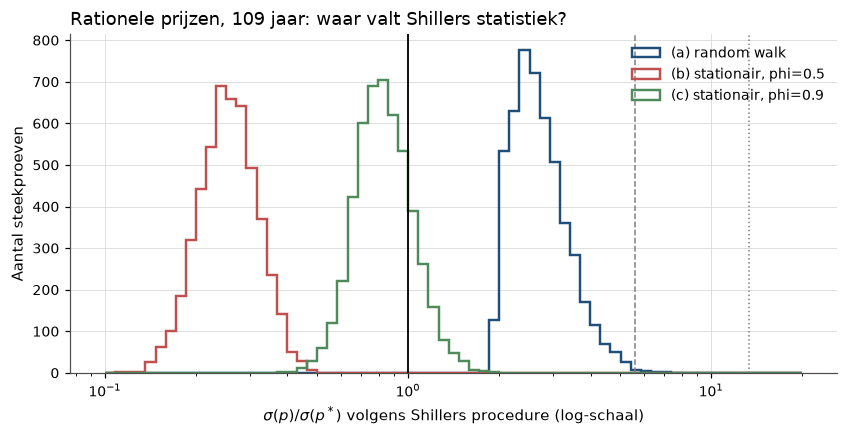

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.logspace(np.log10(0.1), np.log10(20), 70)
for name, values in ratios.items():
    ax.hist(values, bins=bins, histtype="step", lw=1.6, label=name)
ax.axvline(1.0, color="black", lw=1.2)
for value, style in [(5.59, "--"), (13.28, ":")]:
    ax.axvline(value, color="grey", lw=1.0, ls=style)
ax.set_xscale("log")
ax.set_xlabel(r"$\sigma(p)/\sigma(p^*)$ volgens Shillers procedure (log-schaal)")
ax.set_ylabel("Aantal steekproeven")
ax.set_title("Rationele prijzen, 109 jaar: waar valt Shillers statistiek?")
ax.legend()
plt.show()

:::{figure} #cel-shiller-excess-volatility-simulatie
:label: fig-shiller-excess-volatility-simulatie
:width: 95%

In alle drie de economieën zijn prijzen exact rationeel, dus rechts van de
zwarte lijn liggen alleen "schendingen" die de toets verzint. Bij random-walk-
dividenden (a) ligt vrijwel de hele verdeling rechts, rond een factor 2,6, en een dunne staart reikt tot Shillers eigen 5,59 (gestreepte lijn). Bij
stationaire dividenden (b) werkt de toets zoals bedoeld. Bij stationaire maar
persistente dividenden (c) schuift de verdeling op naar de grens: de
kleine-steekproefbias van Flavin.
:::

Drie lessen. Ten eerste werkt Shillers toets in de wereld waarvoor hij hem
ontwierp: in (b) valt de ratio in geen enkele steekproef boven één. Ten tweede
maakt persistentie de toets onbetrouwbaar zonder dat er een eenheidswortel
nodig is: in (c) slaat hij in bijna een op de vijf steekproeven vals alarm, omdat het steekproefgemiddelde van een persistente $p^*$ een groot deel van
zijn variantie opslokt. Ten derde is de toets in (a) vrijwel waardeloos. Dat
ligt niet aan de eindwaarde of aan de geschatte $\bar r$: in een aparte proef met
de ware $r$ en de rationele eindprijs bleef het aandeel "schendingen" boven de
90%. Het ligt aan [](#eq-shiller-excess-volatility-kleidon).

Dat Shillers 5,59 in de staart van (a) valt en niet in het midden, is ook
informatief. De simulatie weerlegt Shiller niet; ze laat zien dat zijn getal
alleen iets bewijst als je gelooft dat dividenden rond een bekende trend
schommelen. De laatste controle is die van de stelling zelf: over toestanden,
op een vaste datum, moet de grens in (a) ook gelden.

In [6]:
# Ensemble check in economy (a): p* with the true rate and the rational terminal price
P_T = level[:, -1] * gamma_sim * G / (1 - gamma_sim * G)
pstar_rw = ex_post_price(D_rw, 1 + r_sim, P_T)

check = pd.DataFrame(
    {
        "Var(p_t) over paden": [P_rw[:, t].var() for t in (10, 50, 100)],
        "Var(p*_t) over paden": [pstar_rw[:, t].var() for t in (10, 50, 100)],
    },
    index=pd.Index([10, 50, 100], name="datum t"),
)
check["grens geldt"] = check.iloc[:, 0] <= check.iloc[:, 1]
check.round(2)

,Var(p_t) over paden,Var(p*_t) over paden,grens geldt
datum t,,,
10,131.37,310.10,True
50,4959.91,7762.42,True
100,165479.87,182335.80,True


Over de 5 000 paden op een vaste datum is $\Var(p_t) \le \Var(p^*_t)$, zoals
[](#thm-shiller-excess-volatility-bound) eist, terwijl dezelfde paden langs de
tijd bijna allemaal het omgekeerde laten zien. Dat is het toy-voorbeeld, op
schaal.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Robert J. Shiller, *Do Stock Prices Move Too Much to be Justified by
Subsequent Changes in Dividends?*, American Economic Review 1981
{cite}`Shiller1981`; de latere varianten uit zijn Nobellezing
{cite}`Shiller2014`.

**Wat.** Figuur 1 (gedetrendeerde reële S&P-koers $p$ tegen $p^*$, 1871–1979) en
tabel 2, rij 5–6, kolom 1: $\sigma(p) = 50{,}12$ tegen $\sigma(p^*) = 8{,}968$,
een ratio van 5,59, met $\Corr(p,p^*) = 0{,}3918$, $b = 0{,}0148$ en
$\bar r = 0{,}048$. Daarnaast de variant met tijdvariërende rentes (Nobellezing,
figuur 2) en de log-lineaire grens van Campbell en Shiller.

**Data hier.** Shillers maandreeks via `hap.data.shiller()`: januarikoers
(`real_price`) als $P_t$ en het twaalfmaands dividend van december
(`real_dividend`) als het dividend van jaar $t$, beide gedefleerd met de CPI,
1871–2025; `real_total_return_price` voor rendementen. De reële korte rente is
`Rfree` uit `hap.data.goyal_welch("annual")`, gedefleerd met de januari-CPI.

**Verschil met het origineel.** Shiller defleerde met de groothandelsprijsindex
(WPI), die veel beweeglijker is dan de CPI, en gebruikte het totale dividend van
het kalenderjaar gedeeld door de jaargemiddelde WPI. De Dow-reeks (dataset 2)
is niet gratis beschikbaar; we tonen de S&P over 1928–1979 als benadering.

**Verwachte afwijking.** Op 1871–1979 moet de ratio duidelijk boven één liggen
en in dezelfde orde als 5,59 (tussen 3 en 7), met $b$ en $\bar r$ binnen een paar
tiende procentpunt en een lage correlatie (onder 0,5). Wijkt het *teken* van
$\sigma(p) - \sigma(p^*)$ af, dan zit er een fout in de code. Daarnaast de
Kleidon-voorspelling: over alternatieve keuzes voor detrending en eindwaarde
moet de ratio met minstens een factor vijf variëren, en de log-lineaire ratio
moet veel dichter bij één liggen dan de gedetrendeerde.
```

In [7]:
shiller_raw = hap_data.shiller()
jan = shiller_raw[shiller_raw.index.month == 1]
dec = shiller_raw[shiller_raw.index.month == 12]

annual = pd.DataFrame(
    {
        "P": jan["real_price"].to_numpy(),
        "TR": jan["real_total_return_price"].to_numpy(),
        "cpi": jan["cpi"].to_numpy(),
    },
    index=jan.index.year,
).join(pd.Series(dec["real_dividend"].to_numpy(), index=dec.index.year, name="D"))

rf_nominal = hap_data.goyal_welch("annual")["Rfree"]
annual["rf_real"] = (1 + pd.Series(rf_nominal.to_numpy(), index=rf_nominal.index.year)) / (
    annual["cpi"].shift(-1) / annual["cpi"]
) - 1
annual["R"] = annual["TR"].shift(-1) / annual["TR"] - 1

data = annual.loc[1871:2025]
print(f"steekproef {data.index[0]}–{data.index[-1]}, {len(data)} jaren; "
      f"ontbrekend: {int(data[['P', 'D', 'R', 'rf_real']].isna().sum().sum())}")
data[["P", "D", "R", "rf_real"]].describe().round(4)

steekproef 1871–2025, 155 jaren; ontbrekend: 0


,P,D,R,rf_real
count,155.0000,155.0000,155.0000,155.0000
mean,873.6395,23.2527,0.0860,0.0168
std,1145.4919,16.7312,0.1776,0.0613
min,108.3300,6.6676,-0.3803,-0.1503
25%,230.2543,11.6810,-0.0383,-0.0130
50%,340.1294,17.9979,0.0896,0.0129
75%,906.3146,28.7846,0.2148,0.0355
max,6284.8525,81.9343,0.5310,0.2357


Eerst de originele steekproef, met Shillers conventies.

In [8]:
def run(start, end, **kwargs):
    sub = data.loc[start:end]
    out = shiller_test(sub["P"].to_numpy(), sub["D"].to_numpy(), **kwargs)
    return {key: value[0] for key, value in out.items()}


orig = run(1871, 1979)
pd.DataFrame(
    {
        "hier": [orig["ratio"], orig["corr"], orig["b"], orig["rbar"]],
        "Shiller 1981, tabel 2": [50.12 / 8.968, 0.3918, 0.0148, 0.0480],
    },
    index=["sigma(p)/sigma(p*)", "Corr(p, p*)", "b = ln lambda", "r-streep"],
).round(4)

,hier,"Shiller 1981, tabel 2"
sigma(p)/sigma(p*),3.9344,5.5888
"Corr(p, p*)",0.3578,0.3918
b = ln lambda,0.0135,0.0148
r-streep,0.0456,0.0480


De replicatie haalt de orde van grootte en de conclusie: de gedetrendeerde koers
is bijna vier keer zo beweeglijk als $p^*$ (3,93), tegen 5,59 in het origineel.
Trendgroei en discontovoet liggen binnen een kwart procentpunt van Shillers
waarden, de correlatie binnen 0,04. Dat de ratio lager uitvalt, is grotendeels de deflator: de WPI
schommelde in de negentiende eeuw en rond de wereldoorlogen veel harder dan de
CPI, en maakte Shillers reële prijsreeks dus beweeglijker.

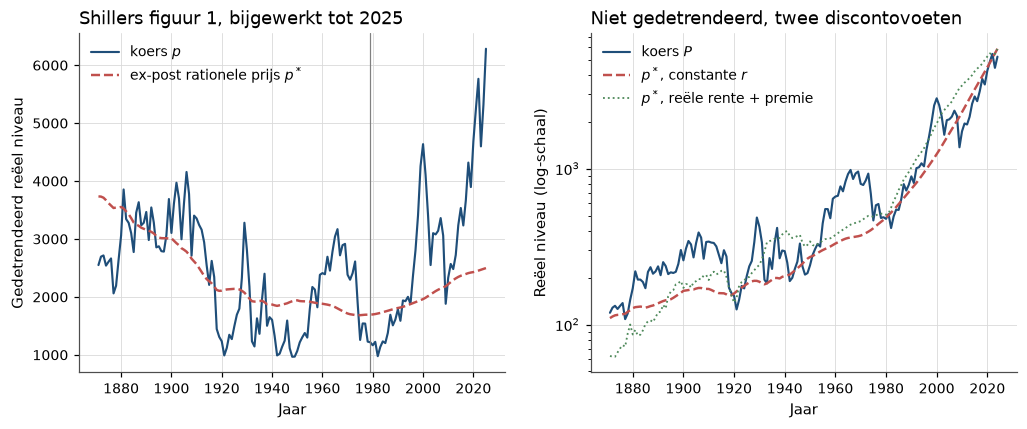

In [9]:
full = run(1871, 2025)
sub = data.loc[1871:2024]
r_const = data["R"].mean()
premium = r_const - data["rf_real"].mean()
pstar_const = ex_post_price(sub["D"].to_numpy(), 1 + r_const, data.loc[2025, "P"])
pstar_rates = ex_post_price(
    sub["D"].to_numpy(), 1 + sub["rf_real"].to_numpy() + premium, data.loc[2025, "P"]
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
yrs = data.index
axes[0].plot(yrs, full["p"], lw=1.4, label="koers $p$")
axes[0].plot(yrs, full["pstar"], lw=1.6, ls="--", label="ex-post rationele prijs $p^*$")
axes[0].axvline(1979, color="grey", lw=0.8)
axes[0].set_xlabel("Jaar")
axes[0].set_ylabel("Gedetrendeerd reëel niveau")
axes[0].set_title("Shillers figuur 1, bijgewerkt tot 2025")
axes[0].legend()

axes[1].plot(sub.index, sub["P"], lw=1.4, label="koers $P$")
axes[1].plot(sub.index, pstar_const, lw=1.6, ls="--", label="$p^*$, constante $r$")
axes[1].plot(sub.index, pstar_rates, lw=1.2, ls=":", label="$p^*$, reële rente + premie")
axes[1].set_yscale("log")
axes[1].set_xlabel("Jaar")
axes[1].set_ylabel("Reëel niveau (log-schaal)")
axes[1].set_title("Niet gedetrendeerd, twee discontovoeten")
axes[1].legend()
plt.show()

:::{figure} #cel-shiller-excess-volatility-figuur1
:label: fig-shiller-excess-volatility-figuur1
:width: 100%

Links: de gedetrendeerde reële S&P-koers en $p^*$ met Shillers conventies
(trend op de koers, $\bar r = \bar d/\bar p$, gemiddelde als eindwaarde); de
verticale lijn markeert het einde van zijn steekproef. Het beeld van 1981
overleeft: $p^*$ kabbelt, de koers niet. Rechts: dezelfde data zonder
detrending op log-schaal, met $p^*$ verdisconteerd tegen het gemiddelde reële
rendement en tegen de reële korte rente plus een constante premie, beide met de
koers van januari 2025 als eindwaarde. Tijdvariërende rentes maken $p^*$
beweeglijker, maar niet op de momenten dat de koers beweegt.
:::

Nu de gevoeligheid. Elke rij hieronder is een verdedigbare keuze die in de
stelling niet voorkomt. De log-lineaire rijen gebruiken
$pd_t = \ln P_t - \ln D_{t-1}$ en $pd^*_t$ uit
[](#eq-shiller-excess-volatility-cs) met gedemeende dividendgroei, zonder
detrending.

In [10]:
def loglinear_bound(start, end, terminal="last"):
    """Campbell-Shiller variance bound on log price-dividend ratios."""
    yrs = np.arange(start, end + 1)
    pd_ratio = np.log(data.loc[yrs, "P"].to_numpy() / data.loc[yrs - 1, "D"].to_numpy())
    growth = np.log(data.loc[yrs, "D"].to_numpy() / data.loc[yrs - 1, "D"].to_numpy())
    rho = np.exp(pd_ratio.mean()) / (1 + np.exp(pd_ratio.mean()))
    x = pd_ratio - pd_ratio.mean()
    end_value = x[-1] if terminal == "last" else 0.0
    # pd*_t = (g_{t+1} - mean g) + rho * pd*_{t+1}: ex_post_price with R = 1/rho and scaled growth
    xstar = ex_post_price((growth - growth.mean()) / rho, 1 / rho, end_value)
    return x.std() / xstar.std(), np.corrcoef(x, xstar)[0, 1]


se_mean_R = data["R"].std() / np.sqrt(len(data))
rows = {
    "1871–1979, Shiller-conventies": run(1871, 1979),
    "1928–1979, Shiller-conventies": run(1928, 1979),
    "1871–2025, Shiller-conventies": full,
    "1871–2025, eindwaarde = laatste koers": run(1871, 2025, terminal="last"),
    "1871–2025, trend op dividenden": run(1871, 2025, detrend="dividend"),
    "1871–2025, r-streep − 2 SE": run(1871, 2025, rate=full["rbar"] - 2 * se_mean_R),
    "1871–2025, r-streep + 2 SE": run(1871, 2025, rate=full["rbar"] + 2 * se_mean_R),
}
table = pd.DataFrame(
    {k: {"sigma(p)/sigma(p*)": v["ratio"], "Corr(p, p*)": v["corr"]} for k, v in rows.items()}
).T

pstar_rates_detr = shiller_test(sub["P"].to_numpy(), sub["D"].to_numpy())
lam = np.exp(pstar_rates_detr["b"][0])
trend = lam ** (np.arange(len(sub)) - (len(sub) - 1))
table.loc["1871–2024, reële rente + premie"] = [
    (sub["P"].to_numpy() / trend).std() / (pstar_rates / trend).std(),
    np.corrcoef(sub["P"].to_numpy() / trend, pstar_rates / trend)[0, 1],
]
for label, (a, b, term) in {
    "log-lineair 1872–2024, eindwaarde = laatste": (1872, 2024, "last"),
    "log-lineair 1872–2024, eindwaarde = gemiddelde": (1872, 2024, "mean"),
    "log-lineair 1872–1979": (1872, 1979, "last"),
}.items():
    table.loc[label] = loglinear_bound(a, b, term)

print(f"SE van het gemiddelde reële rendement: {se_mean_R:.4f}")
table.round(3)

SE van het gemiddelde reële rendement: 0.0143


,sigma(p)/sigma(p*),"Corr(p, p*)"
"1871–1979, Shiller-conventies",3.934,0.358
"1928–1979, Shiller-conventies",9.829,0.314
"1871–2025, Shiller-conventies",1.813,0.464
"1871–2025, eindwaarde = laatste koers",1.105,0.713
"1871–2025, trend op dividenden",9.329,0.604
"1871–2025, r-streep − 2 SE",0.554,0.055
"1871–2025, r-streep + 2 SE",2.360,0.670
"1871–2024, reële rente + premie",0.827,0.586
"log-lineair 1872–2024, eindwaarde = laatste",1.146,0.740
"log-lineair 1872–2024, eindwaarde = gemiddelde",1.899,0.498


De ratio loopt, op dezelfde data en met dezelfde stelling, van ruim een half tot
bijna tien. De drie grootste knoppen zijn precies de keuzes die Kleidon en
Marsh-Merton aanwezen. Een trend op de dividenden in plaats van op de koers
maakt de ratio vijf keer zo groot, omdat de dividenden over de hele eeuw
langzamer groeiden dan de koers en de koers na 1980 daardoor ver boven "zijn"
trend komt te liggen. De werkelijke koers als eindwaarde laat de ratio zakken
naar ongeveer 1,1, omdat $p^*$ na 1990 de koersstijging erft. En de keuze van
de steekproef bepaalt of de jaren negentig erin zitten. Verdisconteren met de
reële korte rente plus een constante premie maakt $p^*$ na detrending zelfs
beweeglijker dan de koers (ratio 0,83): in niveaus is de grens dan niet
geschonden, en wat overblijft is dat $p^*$ en de koers op andere momenten
bewegen (correlatie 0,59).

De onzekerheid over het *gemiddelde* rendement, het 2%-motief, doet er ook toe:
de discontovoet is het gemiddelde van een reeks met een standaardfout van
ongeveer 1,4 procentpunt, en een verschuiving van twee standaardfouten
verplaatst de ratio van 0,55 naar 2,36. Met een discontovoet twee standaardfouten
lager is de grens niet eens geschonden. Een tweede moment is goed meetbaar, maar deze
statistiek bouwt het tweede moment van $p^*$ op uit een eerste moment dat dat
niet is.

De log-lineaire grens is het robuuste antwoord, en ze zegt iets bescheideners:
de log-prijs-dividend-ratio beweegt 1,1 tot 1,9 keer zo veel als de
dividendgroei kan rechtvaardigen, afhankelijk van de eindwaarde. Dat is geen
factor dertien, maar het ligt nog steeds boven één. Wat er boven de één uitsteekt
moet volgens [](#eq-shiller-excess-volatility-decompositie) uit voorspelbare
rendementen komen, precies de helling die [](#01-03-williams-ddm) al vond.

```{warning}
De eindwaarde van $pd^*$ in de laatste jaren van de steekproef is geen detail.
Met de werkelijke eindratio erft $pd^*$ het hoge niveau van na 1995 en lijkt de
grens bijna te gelden; met het gemiddelde als eindwaarde verdwijnt die
bijdrage. Geen van beide is "juist": het verschil is een directe meting van hoe
weinig honderdvijftig jaar data zeggen over wat na 2025 gebeurt.
```

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** De variantiegrens is een van de weinige resultaten
in dit vak die uit bijna niets volgen: een voorspelling is nooit beweeglijker
dan wat ze voorspelt. Ze verplaatste de toets van efficiëntie van de vraag
"kun je morgen rijk worden?", waarop het antwoord nee was, naar de vraag of
koersniveaus te rijmen zijn met fundamentele waarde. En ze leverde een beeld op,
de koers tegen $p^*$, dat een generatie economen overtuigde dat de korte-termijn-
onvoorspelbaarheid uit [](#02-06-efficiente-markten) niet hetzelfde is als juiste
prijzen.

**Waar het breekt.** Niet in de ongelijkheid maar in haar meting. Onze
replicatie geeft 3,9 op Shillers steekproef en tussen 0,55 en 9,3 op de volledige
steekproef, afhankelijk van keuzes die de stelling niet voorschrijft; met een
iets lagere discontovoet of met de reële rente als discontovoet is de grens in
niveaus niet geschonden. De
simulatie laat zien dat een random-walk-economie met exact rationele prijzen de
gedetrendeerde toets bijna altijd "schendt". De robuuste log-lineaire versie
blijft boven één, maar is geen factor vijf tot dertien. Wat overeind blijft is
een kwalitatief feit: de prijs-dividend-ratio beweegt meer dan dividendnieuws
kan dragen, en dat surplus is statistisch hetzelfde als voorspelbaarheid van
rendementen.

**Risico of vergissing?** De Chicago-lezing, met Cochrane
{cite}`Cochrane1992,Cochrane2011` als woordvoerder: de discontovoet varieert. De
aanname van Williams die Shiller toetste was constante $r$, en die is verworpen,
niet de rationaliteit van beleggers. In recessies eisen beleggers meer, dus zijn
prijzen laag en rendementen daarna hoog. De Yale-lezing, van Shiller zelf in zijn
Nobellezing {cite}`Shiller2014`: de discontovoet die nodig is, moet zo wild
bewegen op momenten dat geen gemeten rente of consumptiereeks beweegt. Zijn
figuur met rente- en consumptieverdisconteerde $p^*$ toont weinig overeenkomst
met de koers, en ook hier volgt de rente-variant de koers slecht (correlatie
0,59) terwijl hij even beweeglijk is. Het ligt volgens Shiller meer voor de hand dat koersen reageren op wisselende stemmingen, *animal spirits*. Beide
lezingen voorspellen [](#eq-shiller-excess-volatility-decompositie) met een grote
rendementscovariantie. Ze verschillen pas als je een onafhankelijke meting van
de discontovoet hebt, en die bestond in 1988 niet en bestaat vandaag nauwelijks.
Praktisch betekent het voor Santa-Clara's motief: wie een hoge
prijs-dividend-ratio verkoopt, draagt ofwel een beloonde premie omlaag, ofwel
denkt hij iets te weten wat de prijs niet weet.

**Wat er daarna kwam.** Als geaggregeerde koersen te veel bewegen, zou je
verwachten dat ook individuele aandelen die "goedkoop" zijn ten opzichte van
winst of boekwaarde later meer opbrengen; dat is precies wat Basu, Banz en
Rosenberg in de cross-sectie vonden, zie [](#03-16-vroege-anomalieen).

## Oefeningen

:::{exercise}
:label: ex-shiller-excess-volatility-1

**Een derde informatiestructuur.** Neem het toy-voorbeeld en voeg structuur C
toe: op $t = 0$ zijn $d_1$ en $d_2$ al bekend, $d_3$ niet.

1. Bereken $\Var(p^C_0)$ over de acht toestanden met de hand.
2. Controleer de keten $\Var(p^A_0) \le \Var(p^B_0) \le \Var(p^C_0) \le \Var(p^*_0)$
   en de decompositie $\Var(p^*_0) = \Var(p^C_0) + \Var(p^*_0 - p^C_0)$ in code.
3. Welke informatiestructuur geeft $\Var(p_0) = \Var(p^*_0)$, en wat is dan de
   voorspelfout?
:::

:::{solution} ex-shiller-excess-volatility-1
:class: dropdown

**(1)** $p^C_0 = 0{,}8\,d_1 + 0{,}64\,d_2 + 0{,}512 \times 10$, dus
$\Var(p^C_0) = 25\,(0{,}64 + 0{,}4096) = 26{,}24$.

In [11]:
price_C = 0.8 * states[:, 0] + 0.64 * states[:, 1] + 0.512 * 10
chain = [price_A.var(), price_B.var(), price_C.var(), pstar_0.var()]
print("A, B, C, p* :", np.round(chain, 4), "  oplopend:", bool(np.all(np.diff(chain) >= 0)))
print("Var(p*) - Var(p_C) - Var(u_C) =",
      round(pstar_0.var() - price_C.var() - (pstar_0 - price_C).var(), 12))

A, B, C, p* : [ 0.     16.     26.24   32.7936]   oplopend: True
Var(p*) - Var(p_C) - Var(u_C) = -0.0


**(3)** Volledige kennis van $d_1, d_2, d_3$: dan is $p_0 = p^*_0$ en de
voorspelfout identiek nul. Wat de oefening over het hoofdargument leert: elke
extra informatie maakt de rationele prijs beweeglijker, en $p^*$ is precies het
plafond dat bij volledige informatie hoort. Een koers boven dat plafond kan dus
niet uit méér informatie komen.
:::

:::{exercise}
:label: ex-shiller-excess-volatility-2

**Kleidon in getallen.** Gebruik [](#thm-shiller-excess-volatility-kleidon).

1. Bereken $\sigma(\Delta p)/\sigma(\Delta p^*)$ voor $r \in \{0{,}02;\ 0{,}048;\ 0{,}10\}$.
2. Simuleer één pad van 200 000 jaar met $d_{t+1} = d_t + \varepsilon_{t+1}$,
   $\varepsilon \sim N(0,1)$ en $r = 0{,}048$. Benader $p^*_t$ met 400 termen plus
   de rationele eindprijs, en vergelijk de gemeten ratio met de formule.
3. Leg in twee zinnen uit waarom de ratio *toeneemt* als $r$ daalt.
:::

:::{solution} ex-shiller-excess-volatility-2
:class: dropdown

In [12]:
for r_val in (0.02, 0.048, 0.10):
    g_val = 1 / (1 + r_val)
    print(f"r = {r_val:5.3f}: formule {np.sqrt(1 - g_val**2) / (r_val * g_val):6.2f}")

r_ex, n_long, horizon = 0.048, 200_000, 400
g_ex = 1 / (1 + r_ex)
d_long = np.cumsum(rng.normal(0.0, 1.0, n_long))
p_long = d_long / r_ex
window = np.lib.stride_tricks.sliding_window_view(d_long[1:], horizon)
pstar_long = window @ g_ex ** np.arange(1, horizon + 1) + g_ex**horizon * p_long[horizon:]
m = len(pstar_long)
print(f"gesimuleerd (r = 0.048): "
      f"{np.diff(p_long[:m]).std() / np.diff(pstar_long).std():.2f}")

r = 0.020: formule  10.05
r = 0.048: formule   6.53
r = 0.100: formule   4.58


gesimuleerd (r = 0.048): 6.54


De gesimuleerde ratio ligt binnen enkele procenten van de formule, $6{,}53$.
**(3)** Een lagere $r$ maakt de rationele prijs $d_t/r$ gevoeliger voor elke
permanente dividendschok, terwijl $p^*$ die schok over steeds meer jaren
uitsmeert. Wat de oefening over het hoofdargument leert: juist bij de lage
discontovoeten waarmee Shiller rekende, is de tijdreeks van een rationele prijs
het beweeglijkst ten opzichte van $p^*$.
:::

:::{exercise}
:label: ex-shiller-excess-volatility-3

**De naoorlogse steekproef.** Herhaal de gevoeligheidstabel voor 1950–2025:
Shillers conventies, de laatste koers als eindwaarde, de trend op dividenden, en
de log-lineaire grens met beide eindwaarden. Is de conclusie "de prijs beweegt
te veel" in alle vijf varianten dezelfde?
:::

:::{solution} ex-shiller-excess-volatility-3
:class: dropdown

In [13]:
post = {
    "Shiller-conventies": run(1950, 2025)["ratio"],
    "eindwaarde = laatste koers": run(1950, 2025, terminal="last")["ratio"],
    "trend op dividenden": run(1950, 2025, detrend="dividend")["ratio"],
    "log-lineair, laatste": loglinear_bound(1950, 2024, "last")[0],
    "log-lineair, gemiddelde": loglinear_bound(1950, 2024, "mean")[0],
}
pd.Series(post, name="sigma(p)/sigma(p*), 1950–2025").round(3)

Shiller-conventies             3.002
eindwaarde = laatste koers     2.050
trend op dividenden           12.135
log-lineair, laatste           1.341
log-lineair, gemiddelde        2.074
Name: sigma(p)/sigma(p*), 1950–2025, dtype: float64

De ratio ligt in alle varianten boven één, maar de omvang verschilt met bijna een
factor tien, van 1,34 (log-lineair, laatste eindwaarde) tot 12,1 (trend op
dividenden). Wat de oefening over het hoofdargument leert: het teken
van excess volatility is robuust over steekproeven en conventies, de omvang niet.
Met 75 jaar zeer persistente data is dat precies wat Flavin en Kleidon zouden
voorspellen.
:::